        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-06-13 03:49:52.019680: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749766792.040950 3591913 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749766792.047573 3591913 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-13 03:49:52.069722: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [4]:
# # include ../dirx 
mylibpath = [
    # '/home/kishor/src/FastDWTConvLayers',
    # '/home/kishor/src/MRSegmentation/Attentions19102023'
      # '/home/k/src/_MEDCNNsrc_part/MEDCNN_copy'
      '/home/kishoretarafdar/bin'
      # '/home/kishor/src/MEDCNN_copy'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
import tensorflow as tf

In [5]:
gpus = tf.config.list_physical_devices('GPU')
memory_limit = 30
select_a_gpu(gpus, gpu_id=2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

Virtual devices cannot be modified after being initialized


        GPU status...

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)

Num GPUs Available:  0


2025-06-13 03:49:56.273086: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-06-13 03:49:56.273128: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: meherangarh
2025-06-13 03:49:56.273135: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: meherangarh
2025-06-13 03:49:56.273236: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 570.148.8
2025-06-13 03:49:56.273259: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.148.8
2025-06-13 03:49:56.273265: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 570.148.8


0

# Batched multichannel DST and IDST 3D Layer

        exported to py file DSTIDST3Dv1.py
        exported to py file DSTIDST3Dv001.py

In [3]:
# # include ../dirx 
mylibpath = [
    '/data1/kishoretarafdar/src.port/DST.v0/shearlet.layers',
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath
from DSTIDST3Dv1 import DST3D
import time


        check perfect reconstruction

In [4]:
import tensorflow as tf
import numpy as np
n = 64
axis1 = np.arange(0,n)
x = np.einsum('i,j->ij', axis1, axis1)
x = np.einsum('i,j,k->ijk', axis1, axis1, axis1)
xx = tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0)
xx = tf.concat([xx,xx, xx], axis=-1)
xx.shape
# viz(x)
dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db10')
dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
# dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='rbio1.5')
dst3D.forward(xx).shape
xxrec = dst3D.inverse(dst3D(xx))
xxrec.dtype, xxrec.shape
print(f"\nReconstruction error: {tf.reduce_sum(tf.abs(xxrec - tf.cast(xx,dtype=tf.float64)))}\n")

[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]

Reconstruction error: 5.959486061027837e-06



        A perfect reconstruction system

In [5]:
c = 2
input_shape = (n,n,n,c)
inputs = tf.keras.Input(input_shape)

H  = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
Hr = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5', transform='inverse')
q = H(inputs)
outputs = Hr(q)
# outputs = q
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()

[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 64, 2)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dst3d_2 (DST3D)                 │ (None, 2, 63, 64, 64,  │             0 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ IDST3D (DST3D)                  │ (None, 64, 64, 64, 2)  │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

        inverse layer

In [ ]:
c = 2
input_shape = (c,63,n,n,n)
inputs = tf.keras.Input(input_shape)

# H  = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
Hr = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5', transform='inverse')
q = Hr(inputs)
# outputs = Hr(q)
outputs = q
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()

[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2, 63, 64, 64,  │             0 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dst3d_5 (DST3D)                 │ (None, 64, 64, 64, 2)  │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

    Visualize perfect reconstruction

In [ ]:
n = 64
axis1 = np.arange(0,n)
x = np.einsum('i,j->ij', axis1, axis1)
x = np.einsum('i,j,k->ijk', axis1, axis1, axis1)
xx = tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0)
xx = tf.concat([xx, np.log(xx), np.tan(xx)], axis=-1)
xx.shape

/tmp/ipykernel_3574606/3835140250.py:6: RuntimeWarning: divide by zero encountered in log
  xx = tf.concat([xx, np.log(xx), np.tan(xx)], axis=-1)
/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/tensorflow/python/ops/gen_array_ops.py:1298: RuntimeWarning: invalid value encountered in cast
  _result = pywrap_tfe.TFE_Py_FastPathExecute(


TensorShape([1, 64, 64, 64, 3])

In [ ]:
# viz(x)
dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db10')
dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='bior1.5')
# dst3D = DST3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave='rbio1.5')
dst3D.forward(xx).shape
xxrec = dst3D.inverse(dst3D(xx))
xxrec.dtype, xxrec.shape
print(f"\nReconstruction error: {tf.reduce_sum(tf.abs(xxrec - tf.cast(xx,dtype=tf.float64)))}\n")

[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]

Reconstruction error: 38548447.985660896



Volume range: -9223372036854775808.000 to 12.000 — using level=-4611686018427387904.000
Volume range: -9223372036854775808.000 to 1704.714 — using level=-4611686018427386880.000


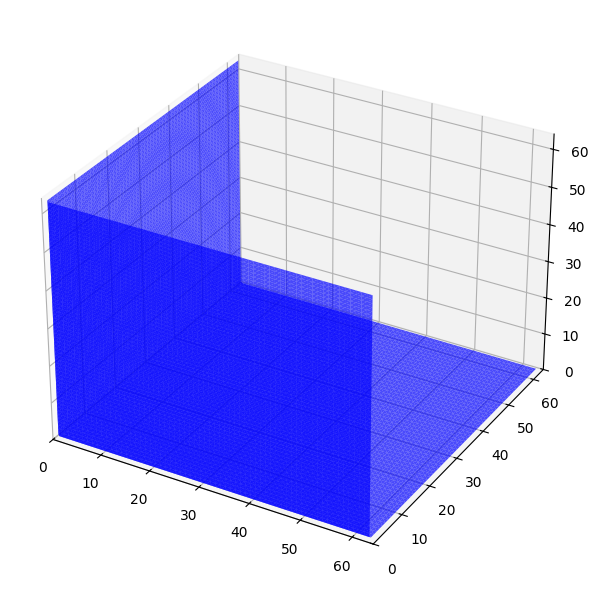

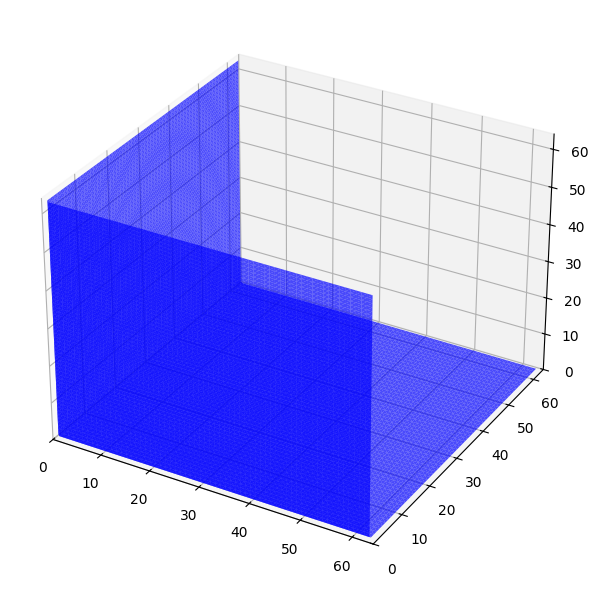

In [ ]:
bat = 0
ch = 1
viz(xx[bat,:,:,:,ch].numpy())
viz(xxrec[bat,:,:,:,ch].numpy())

---

#        visualize the fitlers

In [ ]:
sys3d = dst3D.shearlet_system
[_.shape for _ in sys3d]

[TensorShape([1, 64, 64, 64]),
 TensorShape([10, 64, 64, 64]),
 TensorShape([8, 64, 64, 64]),
 TensorShape([8, 64, 64, 64])]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def viz(volume, level=None):
    L = volume.shape[1]

    # Compute a level within the range of the volume data
    min_val = np.min(volume)
    max_val = np.max(volume)
    if level==None:
        level = (min_val + max_val) * 0.5  # Midpoint level
    # level = np.mean()

    # Debug print to confirm the range
    print(f"Volume range: {min_val:.3f} to {max_val:.3f} — using level={level:.3f}")

    # Extract mesh with marching cubes
    verts, faces, _, _ = measure.marching_cubes(volume, level=level)

    # Plot
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(verts[faces], alpha=0.7)
    mesh.set_facecolor('b')
    ax.add_collection3d(mesh)

    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_zlim(0, L)
    plt.tight_layout()
    # plt.show()

# for el in sys3d
[el.shape for el in sys3d]
[el.dtype for el in sys3d]
# viz(np.squeeze(tf.signal.fftshift(sys3d[0])))

[tf.float64, tf.float64, tf.float64, tf.float64]

Volume range: 0.000 to 1.116 — using level=0.558
5


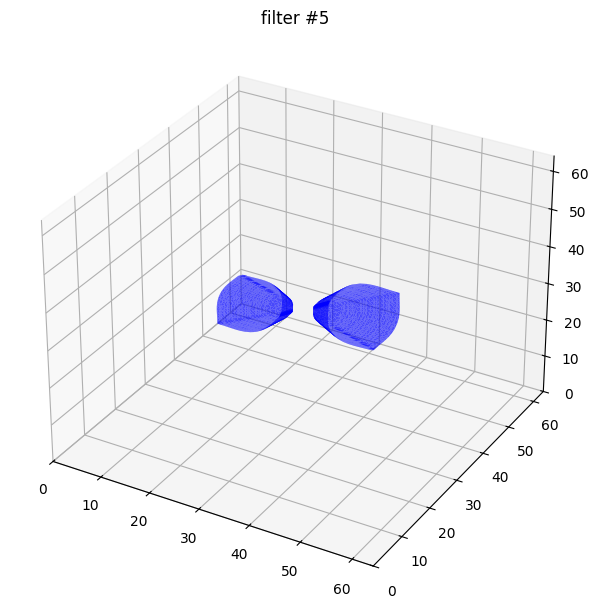

In [ ]:
# s = np.random.randint(sys3d[1].shape[0])
# viz(np.squeeze(tf.signal.fftshift(sys3d[1][s,...]))), plt.title(f'filter #{s}')
# s = np.random.randint(sys3d[2].shape[0])
# viz(np.squeeze(tf.signal.fftshift(sys3d[2][s,...]))), plt.title(f'filter #{s}')
s = np.random.randint(sys3d[3].shape[0])
viz(np.squeeze(tf.signal.fftshift(sys3d[3][s,...]))), plt.title(f'filter #{s}')
# s=0 #override!!
print(s)




Volume range: 0.000 to 1.000 — using level=0.500


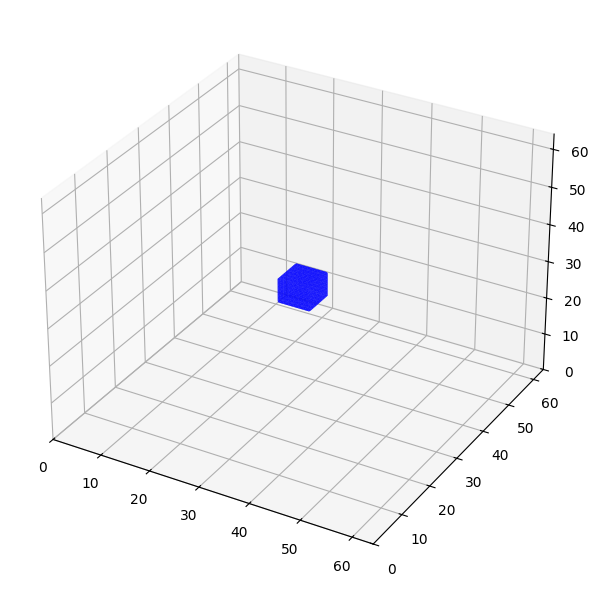

Volume range: 0.000 to 2.250 — using level=1.125


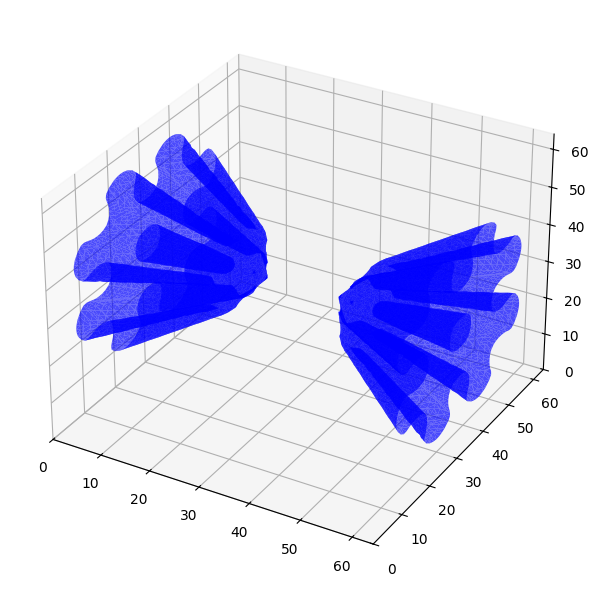

Volume range: 0.000 to 1.806 — using level=0.903


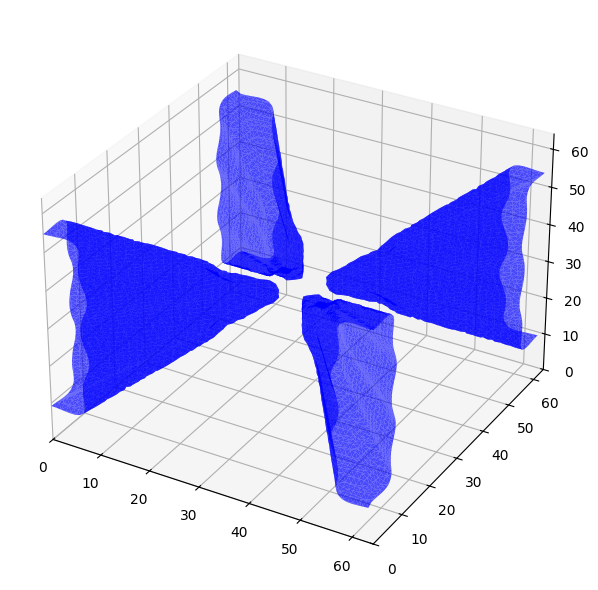

Volume range: 0.000 to 1.511 — using level=0.756


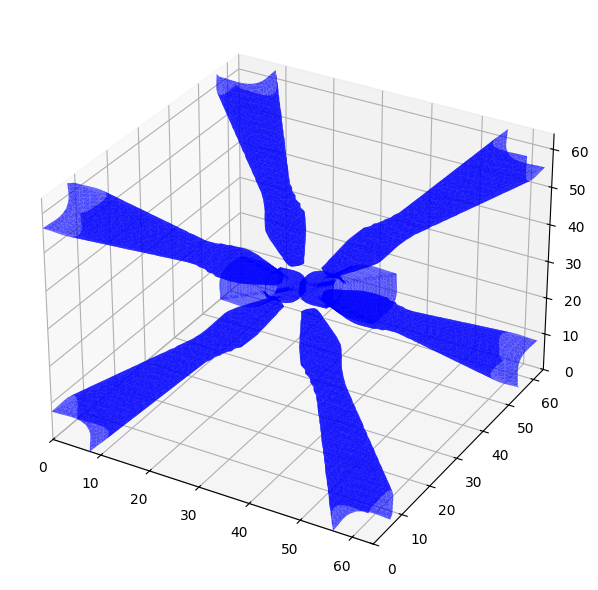

In [ ]:
for i,el in enumerate(sys3d):
  _ = tf.reduce_sum(el, axis=0)
  viz(np.squeeze(tf.signal.ifftshift(_)))
  # viz(np.real(np.squeeze(tf.signal.fftshift(tf.signal.fft(tf.cast(_,tf.complex64))))))
  plt.show()


    view all filters in one combined plot

[TensorShape([1, 64, 64, 64]), TensorShape([1, 64, 64, 64]), TensorShape([1, 64, 64, 64]), TensorShape([1, 64, 64, 64])]
Volume range: 0.000 to 2.299 — using level=1.150


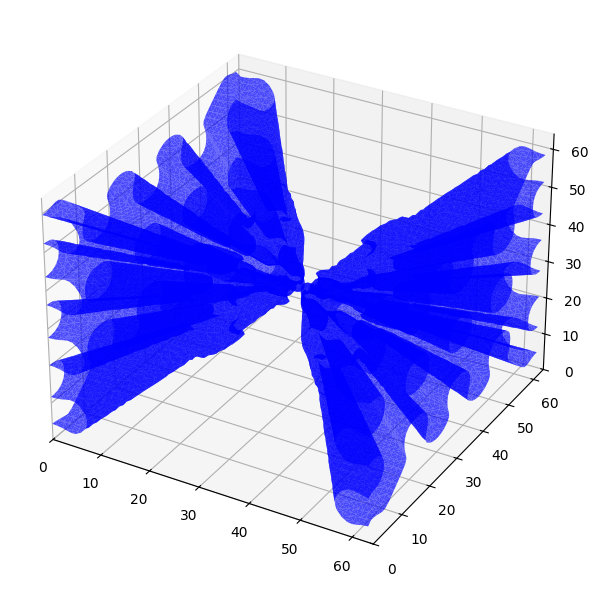

In [ ]:
import tensorflow as tf
_ = [tf.expand_dims(tf.reduce_sum(tf.signal.fftshift(el), axis=0), axis=0) for el in sys3d][:]
print([el.shape for el in _])
_ = tf.concat(_, axis=0)
_ = tf.reduce_sum(_, axis=0)
# _.shape
# for i,el in enumerate(sys3d):
tf.signal.fftshift(_)
#   _ = tf.reduce_sum(el, axis=0)
#   # plt.subplot(1, 4, i+1)
#   # print(i,_.shape, _.dtype)
viz(np.squeeze(_))

[TensorShape([1, 128, 128, 128]), TensorShape([1, 128, 128, 128]), TensorShape([1, 128, 128, 128]), TensorShape([1, 128, 128, 128])]
Volume range: 0.000 to 2.186 — using level=1.093


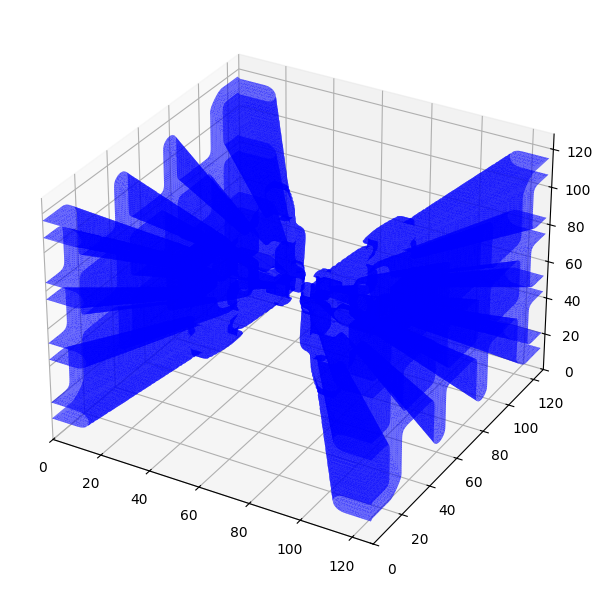

[TensorShape([1, 32, 32, 32]), TensorShape([1, 32, 32, 32]), TensorShape([1, 32, 32, 32]), TensorShape([1, 32, 32, 32])]
Volume range: 0.000 to 2.000 — using level=1.000


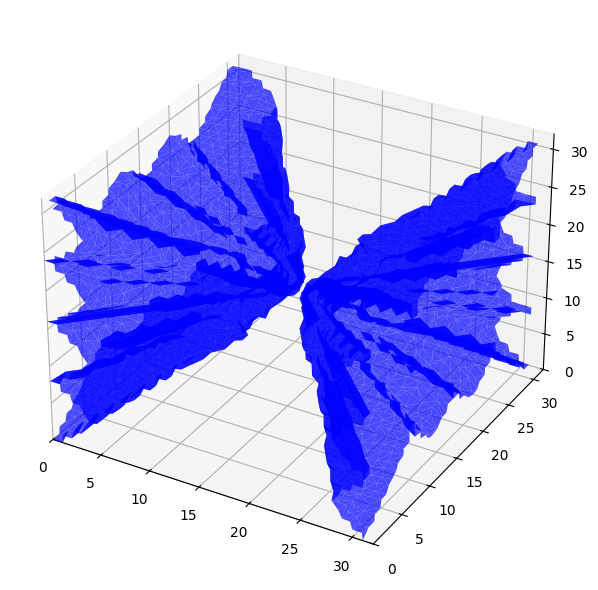

#    View the complete tiling of the 3D space

In [ ]:
print('\nFilter shapes: ',[_.shape for _ in sys3d])


Filter shapes:  [TensorShape([1, 64, 64, 64]), TensorShape([10, 64, 64, 64]), TensorShape([8, 64, 64, 64]), TensorShape([8, 64, 64, 64])]


        Low pass filter (Group 0 with only one LPF)

Volume range: 0.000 to 1.000 — using level=0.500


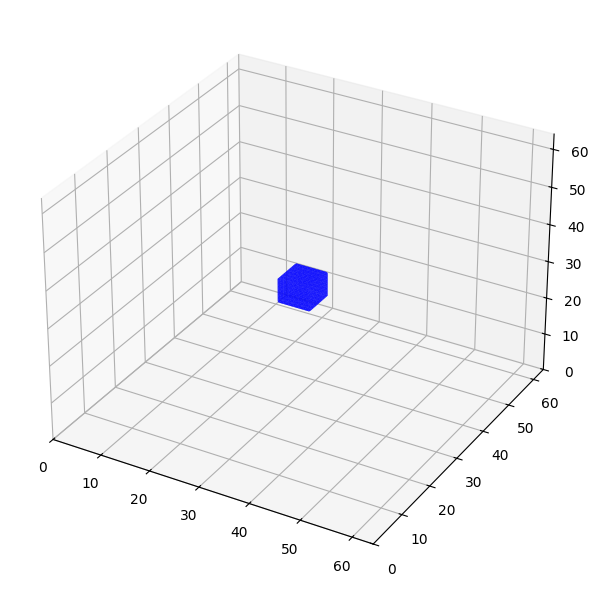

In [ ]:
viz(tf.squeeze(tf.signal.ifftshift(sys3d[0])).numpy())

        Filter Group 1 (from all three 3d planes)

1
Volume range: 0.000 to 2.250 — using level=1.125


TensorShape([64, 64, 64])

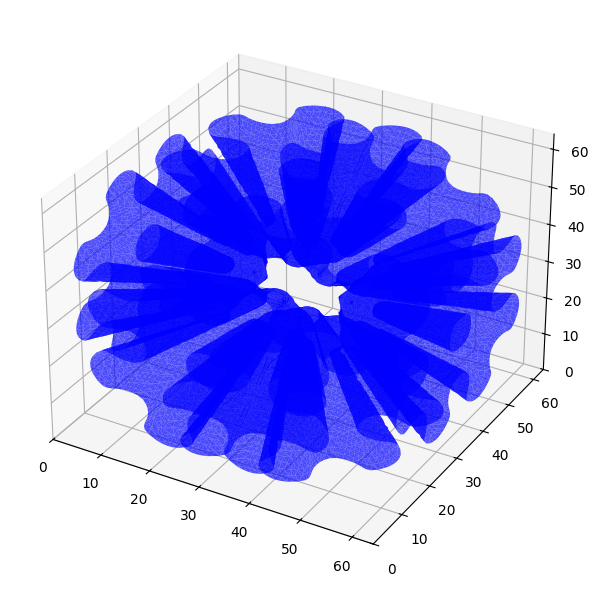

In [ ]:
def get_all_3d_planes(item):
    el1 = tf.reduce_sum(sys3d[item], axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    el2 = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,2,3,1]), axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    el3 = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,3,1,2]), axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    _ =[tf.expand_dims(__, axis=0) for __ in [el1,el2,el3]]
    _ = tf.concat(_, axis=0)
    return tf.reduce_sum(_, axis=0)

item = 1
print(item)
group1 = get_all_3d_planes(item)
viz(tf.signal.ifftshift(group1).numpy())
group1.shape     


        Filter Group 2 (from all three 3d planes)

2
Volume range: 0.000 to 1.806 — using level=0.903


TensorShape([64, 64, 64])

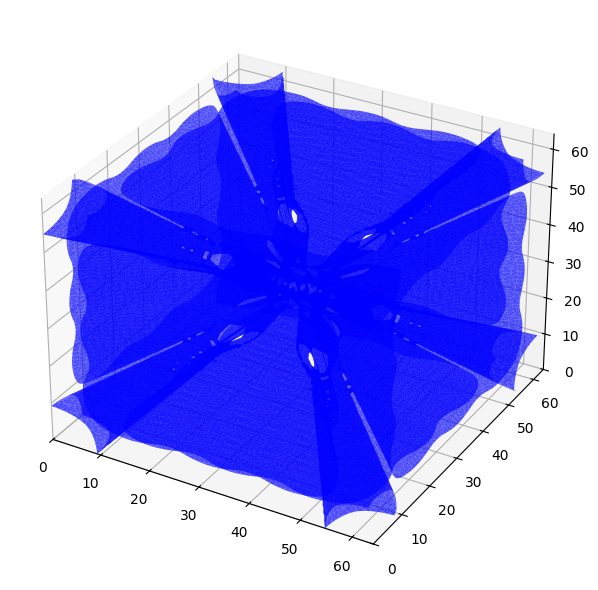

In [ ]:
item = 2
print(item)
group1 = get_all_3d_planes(item)
viz(tf.signal.ifftshift(group1).numpy())
group1.shape     


        Filter Group 3


In [ ]:
tf.signal.ifftshift(sys3d[3]).shape

TensorShape([8, 64, 64, 64])

Volume range: 0.000 to 1.511 — using level=0.756


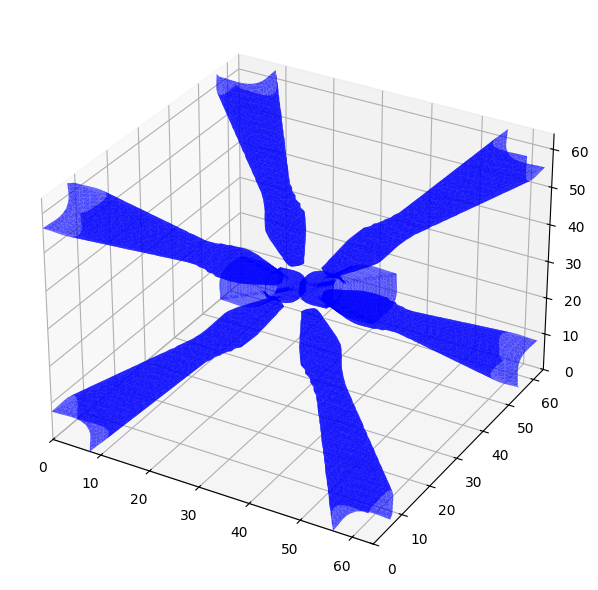

In [ ]:
viz(tf.squeeze(tf.signal.ifftshift(tf.reduce_sum(sys3d[3], axis=0))).numpy())

        all in one

In [ ]:
sys3d[item].dtype

tf.float64

1
2
Volume range: 0.000 to 1.980 — using level=0.990


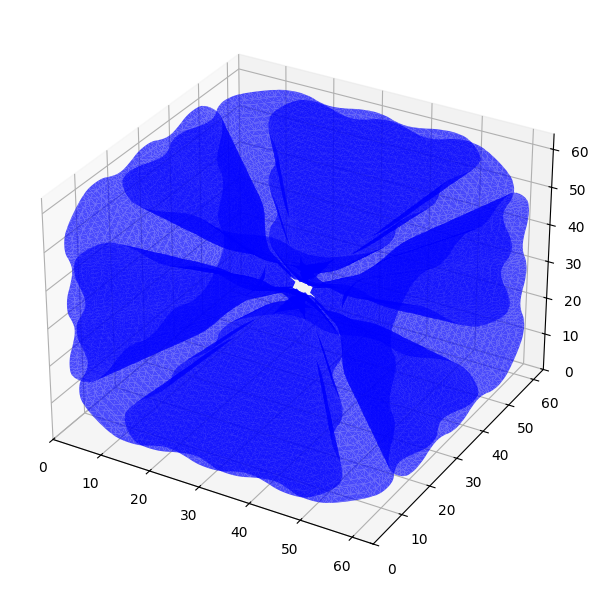

In [ ]:
for item in range(1,3):
    print(item)
    # item = 2
    el1 = tf.reduce_sum(sys3d[item], axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    el2 = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,2,3,1]), axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    el3 = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,3,1,2]), axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    _ =[tf.expand_dims(__, axis=0) for __ in [el1,el2,el3]]
    _ = tf.concat(_, axis=0)
    _ = tf.reduce_sum(_, axis=0)
_12 = _
_12.shape

viz(
    tf.signal.ifftshift(
        tf.squeeze(sys3d[0]) + 
        _12 +
        tf.squeeze(tf.reduce_sum(sys3d[3], axis=0))
        ).numpy())#, level=0.99)

FIGURE ABOVE SHOWS THE COMPLETE TILING OF THE 3D SPACE

---

Volume range: 0.000 to 1.806 — using level=0.903
Volume range: 0.000 to 1.806 — using level=0.903
Volume range: 0.000 to 1.806 — using level=0.903


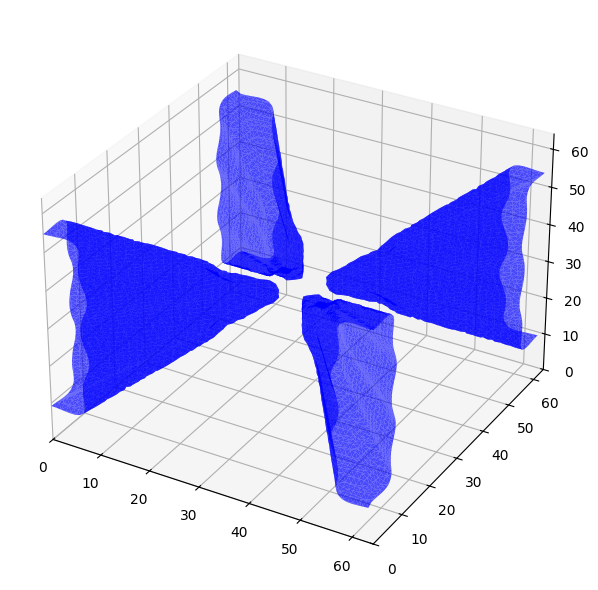

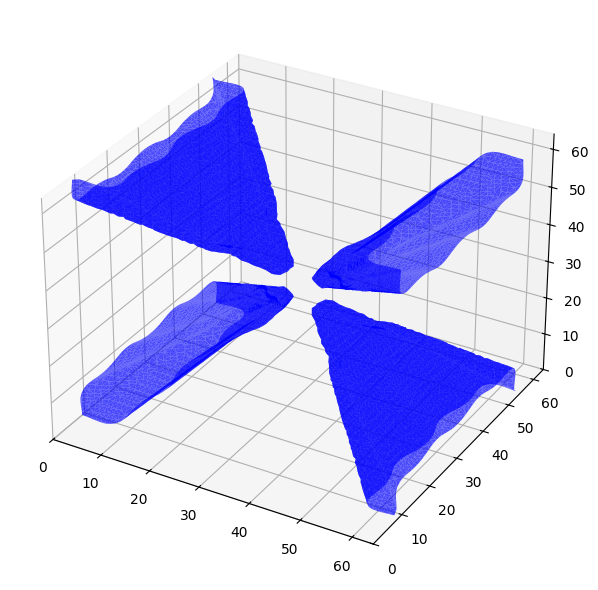

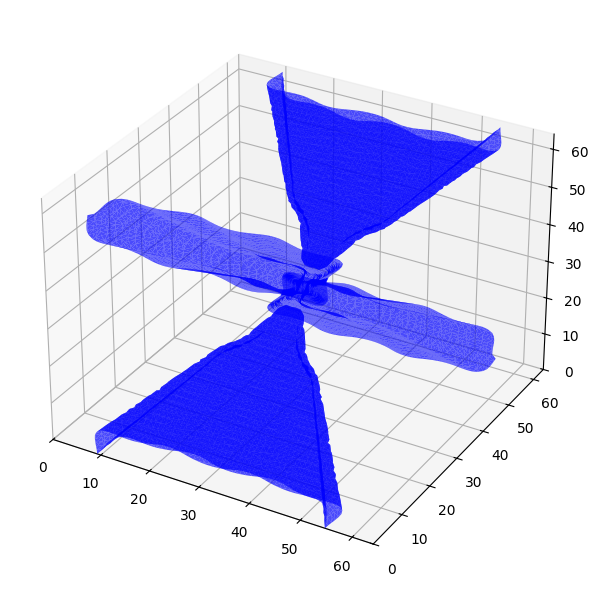

In [ ]:
## Filter g
item = 2
el = tf.reduce_sum(sys3d[item], axis=0)
viz(tf.signal.ifftshift(el).numpy())
el = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,2,3,1]), axis=0)
viz(tf.signal.ifftshift(el).numpy())
el = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,3,1,2]), axis=0)
viz(tf.signal.ifftshift(el).numpy())


Volume range: 0.000 to 1.888 — using level=0.944


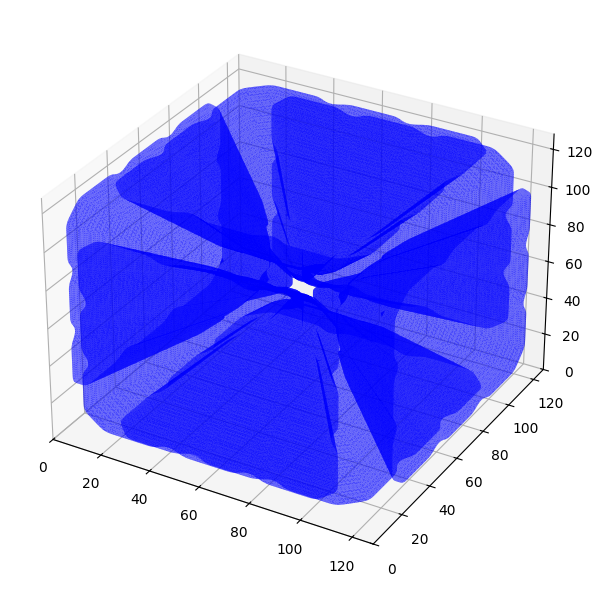

Volume range: 0.000 to 2.184 — using level=1.092


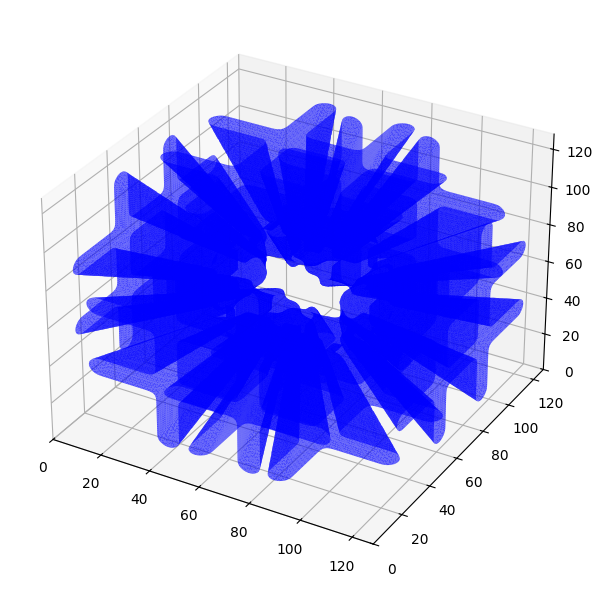

In [ ]:
viz(tf.signal.ifftshift(_1).numpy())

In [ ]:
for item in range(1,3):
    print(item)
    # item = 2
    el1 = tf.reduce_sum(sys3d[item], axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    el2 = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,2,3,1]), axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    el3 = tf.reduce_sum(tf.transpose(sys3d[item], perm=[0,3,1,2]), axis=0)
    # viz(tf.signal.ifftshift(el).numpy())
    _ =[tf.expand_dims(__, axis=0) for __ in [el1,el2,el3]]
    _ = tf.concat(_, axis=0)
    _ = tf.reduce_sum(_, axis=0)
_12 = _
_12.shape

1
2


TensorShape([64, 64, 64])

In [ ]:
np.unique(sys3d[1])

array([0.00000000e+00, 2.74027020e-33, 7.09171358e-33, ...,
       1.11631745e+00, 1.11631745e+00, 1.11631745e+00])

Volume range: 0.000 to 2.916 — using level=1.458


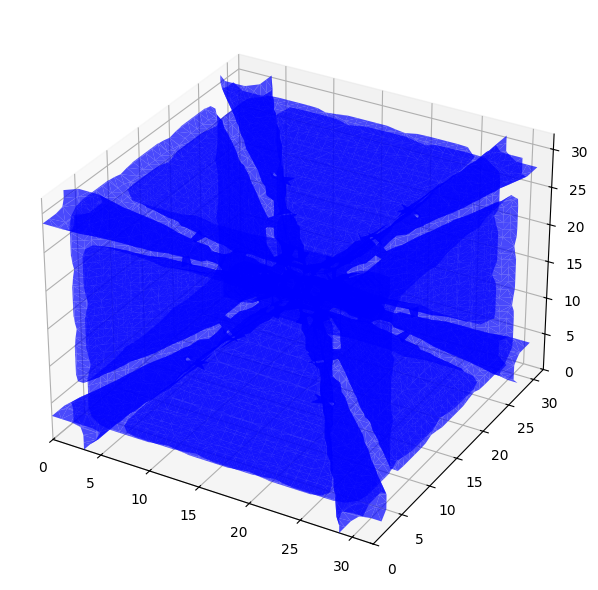

----

#    check perfect reconstruction

In [ ]:
import pywt
pywt.families(short=False)
pywt.wavelist('rbio')

['rbio1.1',
 'rbio1.3',
 'rbio1.5',
 'rbio2.2',
 'rbio2.4',
 'rbio2.6',
 'rbio2.8',
 'rbio3.1',
 'rbio3.3',
 'rbio3.5',
 'rbio3.7',
 'rbio3.9',
 'rbio4.4',
 'rbio5.5',
 'rbio6.8']

In [ ]:
# dst3D.inverse(dst3D(xx))

Volume range: 0.000 to 250047.000 — using level=125023.500
[tf.float64, tf.float64, tf.float64, tf.float64]
[tf.float64, tf.float64, tf.float64, tf.float64]
1.4422404766082764
7114978.854417562 -1218443.9862509936 (63, 64, 64, 64) +
transformed x shape is  (63, 64, 64, 64)
8


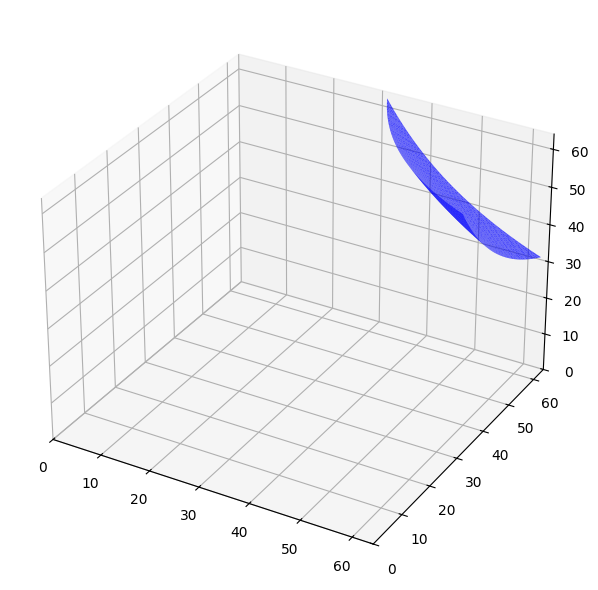

In [ ]:
# # n = 32
# wave = 'db15'
# wave = 'rbio6.8'
# start_time = time.time()
# ST3D = ShearletTransform3D(N=128, J=2, L=[1, 2], B=[4, 8], norm=True)

# # ST3D = ShearletTransform3D(N=128, J=2, L=[1, 2], B=[4, 8], norm=True)
# # ST3D = ShearletTransform3D(N=n, J=2, L=[1, 2], B=[4, 8], norm=True, wave=wave)
# # ST3D = ShearletTransform3D(N=64, J=2, L=[1, 2], B=[4, 8], norm=True, wave='db15')
# print(time.time()-start_time)

# # n=32
# # x = np.random.rand(n,n,n)
# # x = coords.astype(np.float32)
# _ = ST3D(x)
# print(np.max(np.real(_)), np.min(np.real(_)), _.shape, '+')
# _[0,...].dtype,_.shape,np.sum(np.real(_)), np.sum(np.imag(_))

# print('transformed x shape is ',_.shape)
# s = np.random.randint(_.shape[0])
# print(s)
# # viz(np.real(_[s,...]).astype(np.float32)), plt.title(s)

Volume range: -0.000 to 250047.000 — using level=125023.500


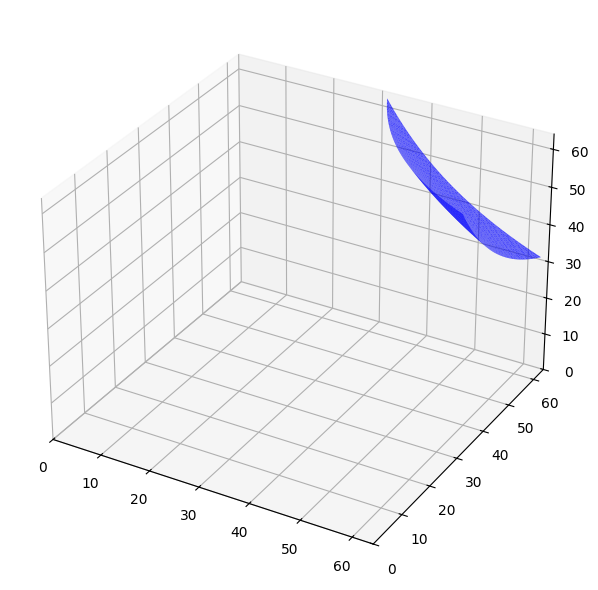

In [ ]:
# ST3D.inverse(ST3D(x)).shape
viz(tf.squeeze(ST3D.inverse(ST3D(x))).numpy())

In [ ]:
isequal = lambda a,b:np.allclose(a, b, rtol=1e-7, atol=1e-7)
isequal(ST3D.inverse(ST3D(x)), x)

True

    shearlet transform of a sample x

# Test signals

        1. Single channel input (1,n,n,1)
    
    Analysis...

In [ ]:
_ = tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0)
coeffs = AnalysisTrans(shearlets)(_)
coeffs.shape, coeffs.dtype

(TensorShape([1, 64, 64, 64, 99]), tf.float64)

In [ ]:
shearlets.shape, shearlets.dtype

((64, 64, 64, 99), dtype('complex128'))

    Synthesis...

In [ ]:
xr = SynthesisTrans(shearlets)(coeffs)
xr.shape, xr.dtype, x.shape

(TensorShape([1, 64, 64, 64, 1]), tf.float64, TensorShape([64, 64, 64]))

In [ ]:
tf.math.reduce_sum(tf.math.imag(xr))

<tf.Tensor: shape=(), dtype=float64, numpy=0.0>

    Perfect reconstruction?

In [ ]:
np.allclose(_, xr, atol=0.006)

True

In [ ]:
del  _, xr, coeffs

In [ ]:
# b = 0
# c = 0
# plt.subplot(121), plt.imshow(_[b,:,:,c]), plt.xticks([]), plt.yticks([]), plt.title('$x$')
# plt.subplot(122), plt.imshow(xr[b,:,:,c]), plt.xticks([]), plt.yticks([]), plt.title('$x_r$')

        2. multichannel input (1,n,n,c)
    
    Analysis...

In [ ]:
_ = tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0)
print(_.shape)
_ = tf.concat([_,_,_], axis=-1)
print(_.shape)
coeffs = AnalysisTrans(shearlets)(_)
coeffs.shape


(1, 64, 64, 64, 1)
(1, 64, 64, 64, 3)


TensorShape([1, 64, 64, 64, 297])

    Synthesis...

In [ ]:
xr = SynthesisTrans(shearlets)(coeffs)
xr.shape, x.shape

(TensorShape([1, 64, 64, 64, 3]), TensorShape([64, 64, 64]))

    Perfect reconstruction?

In [ ]:
np.allclose(_, xr, atol=0.006)

True

In [ ]:
del  _, xr, coeffs

       3. Batched multichannel input (b,n,n,c)

    Analysis...

In [ ]:
_ = tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0)
print(_.shape)
_ = tf.concat([_,_,_], axis=-1)
_ = tf.concat([_,_,_,_], axis=0)
print(_.shape)
coeffs = AnalysisTrans(shearlets)(_)
coeffs.shape


(1, 64, 64, 64, 1)
(4, 64, 64, 64, 3)


TensorShape([4, 64, 64, 64, 297])

    Synthesis...

In [ ]:
xr = SynthesisTrans(shearlets)(coeffs)
xr.shape, x.shape

: 

    Perfect reconstruction?

In [ ]:
np.allclose(_, xr, atol=0.006)

False

(<Axes: title={'center': '$x_r$'}>,
 ([], []),
 ([], []),
 Text(0.5, 1.0, '$x_r$'))

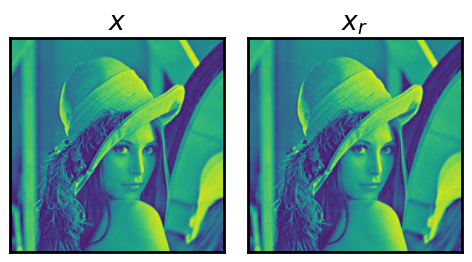

In [ ]:
b = 1
c = 3
plt.subplot(121), plt.imshow(_[b,:,:,c]), plt.xticks([]), plt.yticks([]), plt.title('$x$')
plt.subplot(122), plt.imshow(xr[b,:,:,c]), plt.xticks([]), plt.yticks([]), plt.title('$x_r$')

In [ ]:
_.

In [ ]:
# from tensorflow.signal import fft2d, fftshift, ifftshift 
xfreq = tf.signal.fftshift(tf.signal.fft2d(tf.signal.ifftshift(tf.cast(x, tf.complex128))))
coeffs = tf.stack([tf.signal.fftshift(tf.signal.ifft2d(tf.signal.ifftshift(tf.einsum('ij,ij -> ij', xfreq, shearlets[...,k].conjugate())))) for k in range(shearlets.shape[-1])], axis=-1)
coeffs.shape, coeffs.dtype